# Lab15-1 - CLIP 零樣本分類與檢索


- 使用 `openai/clip-vit-large-patch14` 對 CIFAR-10 test set 做零樣本分類。
- 透過 prompt ensemble 建立文字類別 embedding。
- 使用 image embedding 完成文字到影像相似度比較。
- 輸出 confusion matrix、per-class accuracy 與分類結果表。


## 1. Import 必要套件


In [19]:
%pip install transformers
%pip install scikit-learn

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. 參數與路徑設定


In [ ]:
# 使用 ViT-L/14 版本，取得較穩定的影像與文字 embedding
MODEL_NAME = 'openai/clip-vit-large-patch14'
DATA_ROOT = './data'
RESULTS_DIR = Path('./results')
RETRIEVAL_DIR = RESULTS_DIR / 'retrieval_examples'

for directory in (RESULTS_DIR, RETRIEVAL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 128
NUM_WORKERS = 2

# GPU 推論時使用 fp16 可降低顯存用量並加快 CLIP embedding 計算
USE_FP16 = (DEVICE == 'cuda')

# CIFAR-10 官方類別順序，需與 torchvision 回傳的 label 一致
CIFAR_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

print('classes:', CIFAR_CLASSES)


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. 載入 CIFAR-10 測試資料集


In [21]:
# 保留 PIL.Image，後續交給 CLIPProcessor 做 resize 與 normalize
test_set = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=None,
)

print('test_set size :', len(test_set))
print('first sample  :', type(test_set[0][0]).__name__, test_set[0][0].size, 'label:', test_set[0][1])

# 確認手寫類別順序沒有和資料集 label 對錯
assert test_set.classes == CIFAR_CLASSES, 'CIFAR-10 class order mismatch'


Files already downloaded and verified
test_set size : 10000
first sample  : Image (32, 32) label: 3


## 4. 載入 CLIP 模型


In [ ]:
# 載入預訓練好的CLIP模型
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

# CLIPProcessor 負責影像前處理與文字 tokenize
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

n_params = sum(p.numel() for p in model.parameters())

print(f'CLIP params : {n_params / 1e6:.1f}M')
print('image size  :', processor.image_processor.size)
print('embed dim   :', model.config.projection_dim)


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIP params : 427.6M
image size  : SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)
embed dim   : 768


## 5. 建立 prompt embedding

對每個 CIFAR-10 類別套用多個 prompt template，先各自正規化後平均，
再得到最終的 class embedding。


In [ ]:
# 多個 prompt 取平均，通常比單一 prompt 更穩定
TEMPLATES_7 = [
    'a photo of a {}.',
    'a blurry photo of a {}.',
    'a close-up photo of a {}.',
    'a low resolution photo of a {}.',
    'a bright photo of a {}.',
    'a cropped photo of a {}.',
    'a photo of the small {}.',
]
TEMPLATES_SINGLE = ['a photo of a {}.']


def _to_features(out, projection):
    # 兼容 transformers 不同版本的 get_*_features 回傳格式
    if torch.is_tensor(out):
        return out

    pooler = getattr(out, 'pooler_output', None)
    if pooler is None:
        raise RuntimeError(f'Unexpected output: {type(out)}')

    proj_in = projection.in_features
    proj_out = projection.out_features

    if pooler.shape[-1] == proj_out:
        return pooler
    if pooler.shape[-1] == proj_in:
        return projection(pooler)

    raise RuntimeError(
        f'pooler_output dim {pooler.shape[-1]} matches neither projection in '
        f'({proj_in}) nor out ({proj_out})'
    )

# 
# 將 text encoder 輸出投影到共同 embedding 空間
def _project_text(out):
    return _to_features(out, model.text_projection)

# 
# 將 image encoder 輸出投影到共同 embedding 空間
def _project_image(out):
    return _to_features(out, model.visual_projection)


@torch.no_grad()
def build_text_features(class_names, templates):
    all_class_embeds = []

    for class_name in class_names:
        prompts = [template.format(class_name) for template in templates]
        inputs = processor(text=prompts, return_tensors='pt', padding=True).to(DEVICE)
        feats = _project_text(model.get_text_features(**inputs))

        # 先 normalize 再平均，避免 embedding 長度影響 prompt ensemble
        feats = feats / feats.norm(dim=-1, keepdim=True)
        mean_feat = feats.mean(dim=0)
        mean_feat = mean_feat / mean_feat.norm()
        all_class_embeds.append(mean_feat)

    return torch.stack(all_class_embeds, dim=0)


text_features_7 = build_text_features(CIFAR_CLASSES, TEMPLATES_7)
print('text_features_7 shape:', tuple(text_features_7.shape))


text_features_7 shape: (10, 768)


## 6. 建立 image embedding


In [ ]:
def pil_collate(batch):
    # 保留 PIL.Image list，讓 CLIPProcessor 套用原模型的前處理流程
    images = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return images, labels


loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=pil_collate,
)

all_feats = []
all_labels = []
amp_dtype = torch.float16 if USE_FP16 else torch.float32

with torch.no_grad():
    for images, labels in tqdm(loader, desc='encoding images'):
        inputs = processor(images=images, return_tensors='pt').to(DEVICE)

        with torch.autocast(device_type='cuda', dtype=amp_dtype, enabled=USE_FP16):
            feats = _project_image(model.get_image_features(**inputs))

        # 後續 cosine similarity 改回 fp32，避免 fp16 ranking 不穩
        feats = feats.float()
        feats = feats / feats.norm(dim=-1, keepdim=True)

        all_feats.append(feats.cpu())
        all_labels.append(labels)

image_features = torch.cat(all_feats, dim=0)
labels_all = torch.cat(all_labels, dim=0)



encoding images:   0%|          | 0/79 [00:00<?, ?it/s]

image_features: (10000, 768)
labels_all   : (10000,)


## 7. 實現零樣本分類

image embedding 與 text embedding 都已經 L2 normalize，
因此矩陣乘法即可視為 cosine similarity。


In [ ]:
def evaluate(image_features, text_features, labels):
    # 兩邊都已 L2 normalize，矩陣乘法即為 cosine similarity，去計算text embedding 與 image embedding 的相似度
    logits = image_features @ text_features.cpu().T
    top1 = logits.argmax(dim=-1)
    top5 = logits.topk(5, dim=-1).indices

    acc1 = (top1 == labels).float().mean().item()
    acc5 = (top5 == labels.unsqueeze(-1)).any(dim=-1).float().mean().item()

    per_class = []
    for class_id in range(len(CIFAR_CLASSES)):
        mask = labels == class_id
        class_acc = (top1[mask] == class_id).float().mean().item() if mask.any() else float('nan')
        per_class.append(class_acc)

    return {
        'top1': acc1,
        'top5': acc5,
        'per_class': per_class,
        'pred_top1': top1,
        'pred_top5': top5,
        'logits': logits,
    }


result_7 = evaluate(image_features, text_features_7, labels_all)


7-prompt ensemble | Top-1 = 94.90% | Top-5 = 99.42%


## 8. 評估與視覺化

- `results/confusion_matrix.png`: 10 x 10 row-normalized confusion matrix。
- `results/per_class_accuracy.png`: 每個類別的 Top-1 accuracy。
- `results/classification_results.csv`: 每張圖的 Top-5 預測與 softmax 機率。


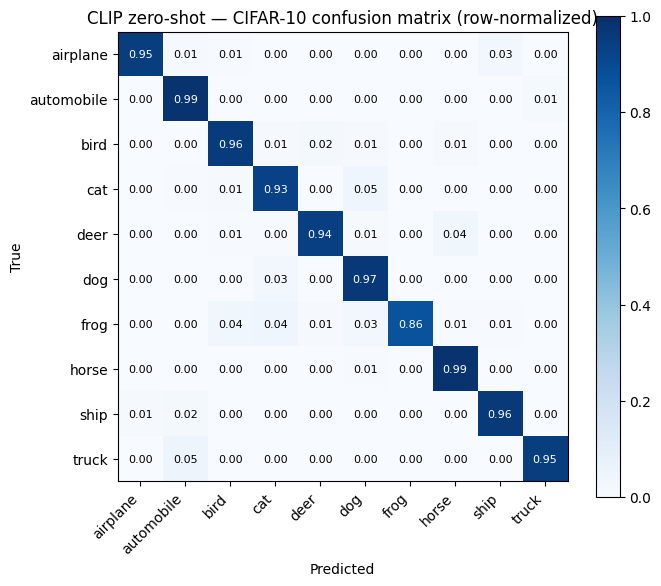

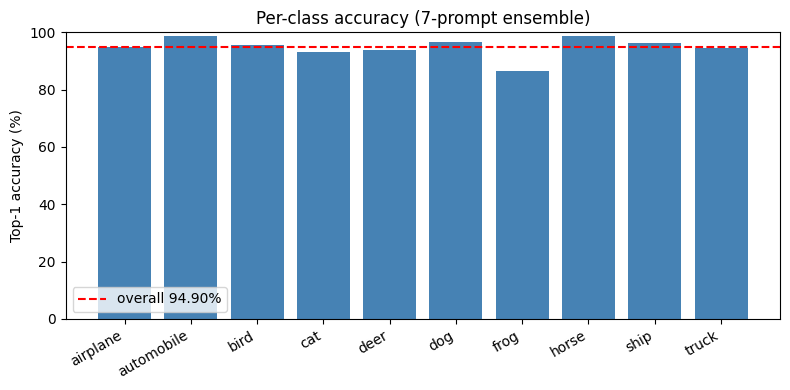

,idx,true,top1,p1,top2,p2,top3,p3,top4,p4,top5,p5
0,0,cat,cat,0.555553,dog,0.111565,bird,0.054254,horse,0.051424,deer,0.050830
1,1,ship,ship,0.995143,automobile,0.003149,truck,0.000524,airplane,0.000293,cat,0.000290
2,2,ship,ship,0.801964,automobile,0.155193,truck,0.011950,bird,0.011910,airplane,0.008218
3,3,airplane,airplane,0.751713,bird,0.182393,automobile,0.046241,ship,0.007593,dog,0.004591
4,4,frog,frog,0.997337,bird,0.001486,dog,0.000487,truck,0.000213,cat,0.000210


In [26]:
# row-normalized confusion matrix 方便比較各類別的混淆比例
cm = confusion_matrix(labels_all.numpy(), result_7['pred_top1'].numpy())
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(CIFAR_CLASSES)))
ax.set_yticks(range(len(CIFAR_CLASSES)))
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CIFAR_CLASSES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('CLIP zero-shot - CIFAR-10 confusion matrix')

for i in range(len(CIFAR_CLASSES)):
    for j in range(len(CIFAR_CLASSES)):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(CIFAR_CLASSES, [acc * 100 for acc in result_7['per_class']], color='steelblue')
ax.set_ylim(0, 100)
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Per-class accuracy')

# 紅線標出整體 accuracy，方便看出哪些類別高於或低於平均
ax.axhline(
    result_7['top1'] * 100,
    color='red',
    ls='--',
    label=f'overall {result_7["top1"] * 100:.2f}%',
)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=120)
plt.show()

# 套用 CLIP 學到的 logit scale 後再 softmax，機率尺度才與訓練時一致
logit_scale = model.logit_scale.exp().detach().cpu().float()
probs = (result_7['logits'] * logit_scale).softmax(dim=-1)

top5_idx = result_7['pred_top5']
rows = []

for i in range(len(labels_all)):
    row = {'idx': i, 'true': CIFAR_CLASSES[labels_all[i].item()]}

    for k in range(5):
        cls_id = top5_idx[i, k].item()
        row[f'top{k + 1}'] = CIFAR_CLASSES[cls_id]
        row[f'p{k + 1}'] = float(probs[i, cls_id])

    rows.append(row)

df_cls = pd.DataFrame(rows)
df_cls.to_csv(RESULTS_DIR / 'classification_results.csv', index=False)
df_cls.head()


## 9. 自訂圖片 prompt 比對

給 CLIP 一張自訂圖片與一組任意 prompt，觀察影像與文字描述的相似度排序。


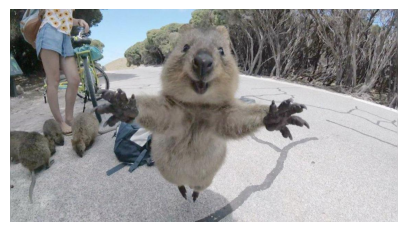

=== CLIP similarity ranking ===
  1. sim=+0.2467  "a photo of a cute animal"
  2. sim=+0.2313  "a photo of a person hugging"
  3. sim=+0.1928  "a photo of someone smiling"
  4. sim=+0.1912  "a photo of a cat"
  5. sim=+0.1880  "a photo of a dog"
  6. sim=+0.1728  "a photo of a car"
  7. sim=+0.1607  "a photo of the Eiffel Tower"
  8. sim=+0.1449  "a photo of someone crying"
  9. sim=+0.1317  "a photo of food on a plate"
  10. sim=+0.0686  "an oil painting of a starry night"


In [ ]:
IMAGE_PATH = 'quokka.jpg'

# 轉成 RGB，避免灰階或透明圖造成 channel 不一致
custom_image = Image.open(IMAGE_PATH).convert('RGB')

# 候選 prompt 涵蓋不同語意，觀察 CLIP 對自由文字描述的排序
CUSTOM_PROMPTS = [
    'a photo of a person hugging',
    'a photo of a cute animal',
    'a photo of a cat',
    'a photo of a dog',
    'a photo of someone crying',
    'a photo of someone smiling',
    'a photo of food on a plate',
    'a photo of the Eiffel Tower',
    'an oil painting of a starry night',
    'a photo of a car',
]

inputs = processor(images=[custom_image], return_tensors='pt').to(DEVICE)
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=amp_dtype, enabled=USE_FP16):
        img_feat = _project_image(model.get_image_features(**inputs))

    img_feat = img_feat.float()
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

# 自由 prompt 各自編碼，不做類別 ensemble
text_inputs = processor(text=CUSTOM_PROMPTS, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    txt_feat = _project_text(model.get_text_features(**text_inputs))
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

sims = (img_feat.cpu() @ txt_feat.cpu().T).squeeze(0)
ranked = sims.argsort(descending=True).tolist()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(custom_image)
ax.axis('off')
plt.show()

print('=== CLIP similarity ranking ===')
for rank, idx in enumerate(ranked, 1):
    print(f'  {rank}. sim={sims[idx].item():+.4f}  "{CUSTOM_PROMPTS[idx]}"')
